## UPI Fraud detection 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
#upiDf=pd.read_csv("transactions_train.csv")
upi=pd.read_csv("transactions_test.csv")

In [3]:
upi.info()
upi.describe()
upi.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99887 entries, 0 to 99886
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   99887 non-null  int64  
 1   transaction_time                 99887 non-null  object 
 2   customer_id                      99887 non-null  int64  
 3   merchant_id                      99887 non-null  int64  
 4   account_age_days                 99887 non-null  int64  
 5   credit_score_band                99887 non-null  int64  
 6   kyc_level                        99887 non-null  int64  
 7   avg_monthly_spend                99887 non-null  float64
 8   merchant_risk_score              99887 non-null  float64
 9   transaction_amount               99887 non-null  float64
 10  payment_channel                  99887 non-null  object 
 11  device_type                      99887 non-null  object 
 12  is_international  

transaction_id                     0
transaction_time                   0
customer_id                        0
merchant_id                        0
account_age_days                   0
credit_score_band                  0
kyc_level                          0
avg_monthly_spend                  0
merchant_risk_score                0
transaction_amount                 0
payment_channel                    0
device_type                        0
is_international                   0
ip_risk_score                      0
txn_count_1h                       0
txn_count_24h                      0
failed_txn_count_24h               0
geo_distance_from_last_txn         0
amount_deviation_from_user_mean    0
is_fraud                           0
post_auth_risk_score               0
dtype: int64

In [4]:
upi.sample(5)
#upidf.columns

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
93998,362129,2023-12-25 15:12:14.875257190,25519,1065,1827,5,3,3305.317591,0.201675,2280.135403,...,desktop,0,0.206916,1,3,0,12.084567,2169.958150,0,0.200063
5377,287158,2023-10-05 23:20:29.101433121,2357,5547,361,5,3,6209.220508,0.097816,5362.426178,...,mobile,0,0.199799,2,1,0,11.523393,5155.452161,0,0.219070
64114,392234,2023-11-28 10:20:04.265941331,14892,6414,39,1,1,970.105226,0.384260,2869.775974,...,mobile,0,0.207740,1,3,3,22.987653,2837.439133,0,0.375635
45598,75037,2023-11-11 10:10:56.904756534,25901,1567,1610,5,3,3688.984589,0.214486,2595.987322,...,desktop,0,0.370775,0,3,1,12.273235,2473.021169,0,0.215106
71263,291016,2023-12-04 21:53:57.973237321,22928,633,54,1,2,6523.198358,0.283675,4458.856751,...,mobile,0,0.608609,3,4,1,21.267448,4241.416806,0,0.292867


## feature Engineering

In [5]:
## converion of datetime to age 
upi.shape

(99887, 21)

In [6]:
col_drop=["post_auth_risk_score","customer_id","merchant_id","merchant_risk_score"]

upi=upi.drop(columns=col_drop,axis=1)
#upi=upi.drop("",aixs=1)

In [7]:
# encoding
upi["transaction_time"] = pd.to_datetime(
    upi["transaction_time"],
    errors="coerce"
)

In [8]:

upi["day"]=upi["transaction_time"].dt.day_name()
upi["day"]

upi["is_weekend"] = upi["day"].isin(
    ["Saturday", "Sunday"]
).astype(int)

In [9]:
upi=upi.drop("day",axis=1)
upi.columns

Index(['transaction_id', 'transaction_time', 'account_age_days',
       'credit_score_band', 'kyc_level', 'avg_monthly_spend',
       'transaction_amount', 'payment_channel', 'device_type',
       'is_international', 'ip_risk_score', 'txn_count_1h', 'txn_count_24h',
       'failed_txn_count_24h', 'geo_distance_from_last_txn',
       'amount_deviation_from_user_mean', 'is_fraud', 'is_weekend'],
      dtype='object')

## outliers Aanlysis

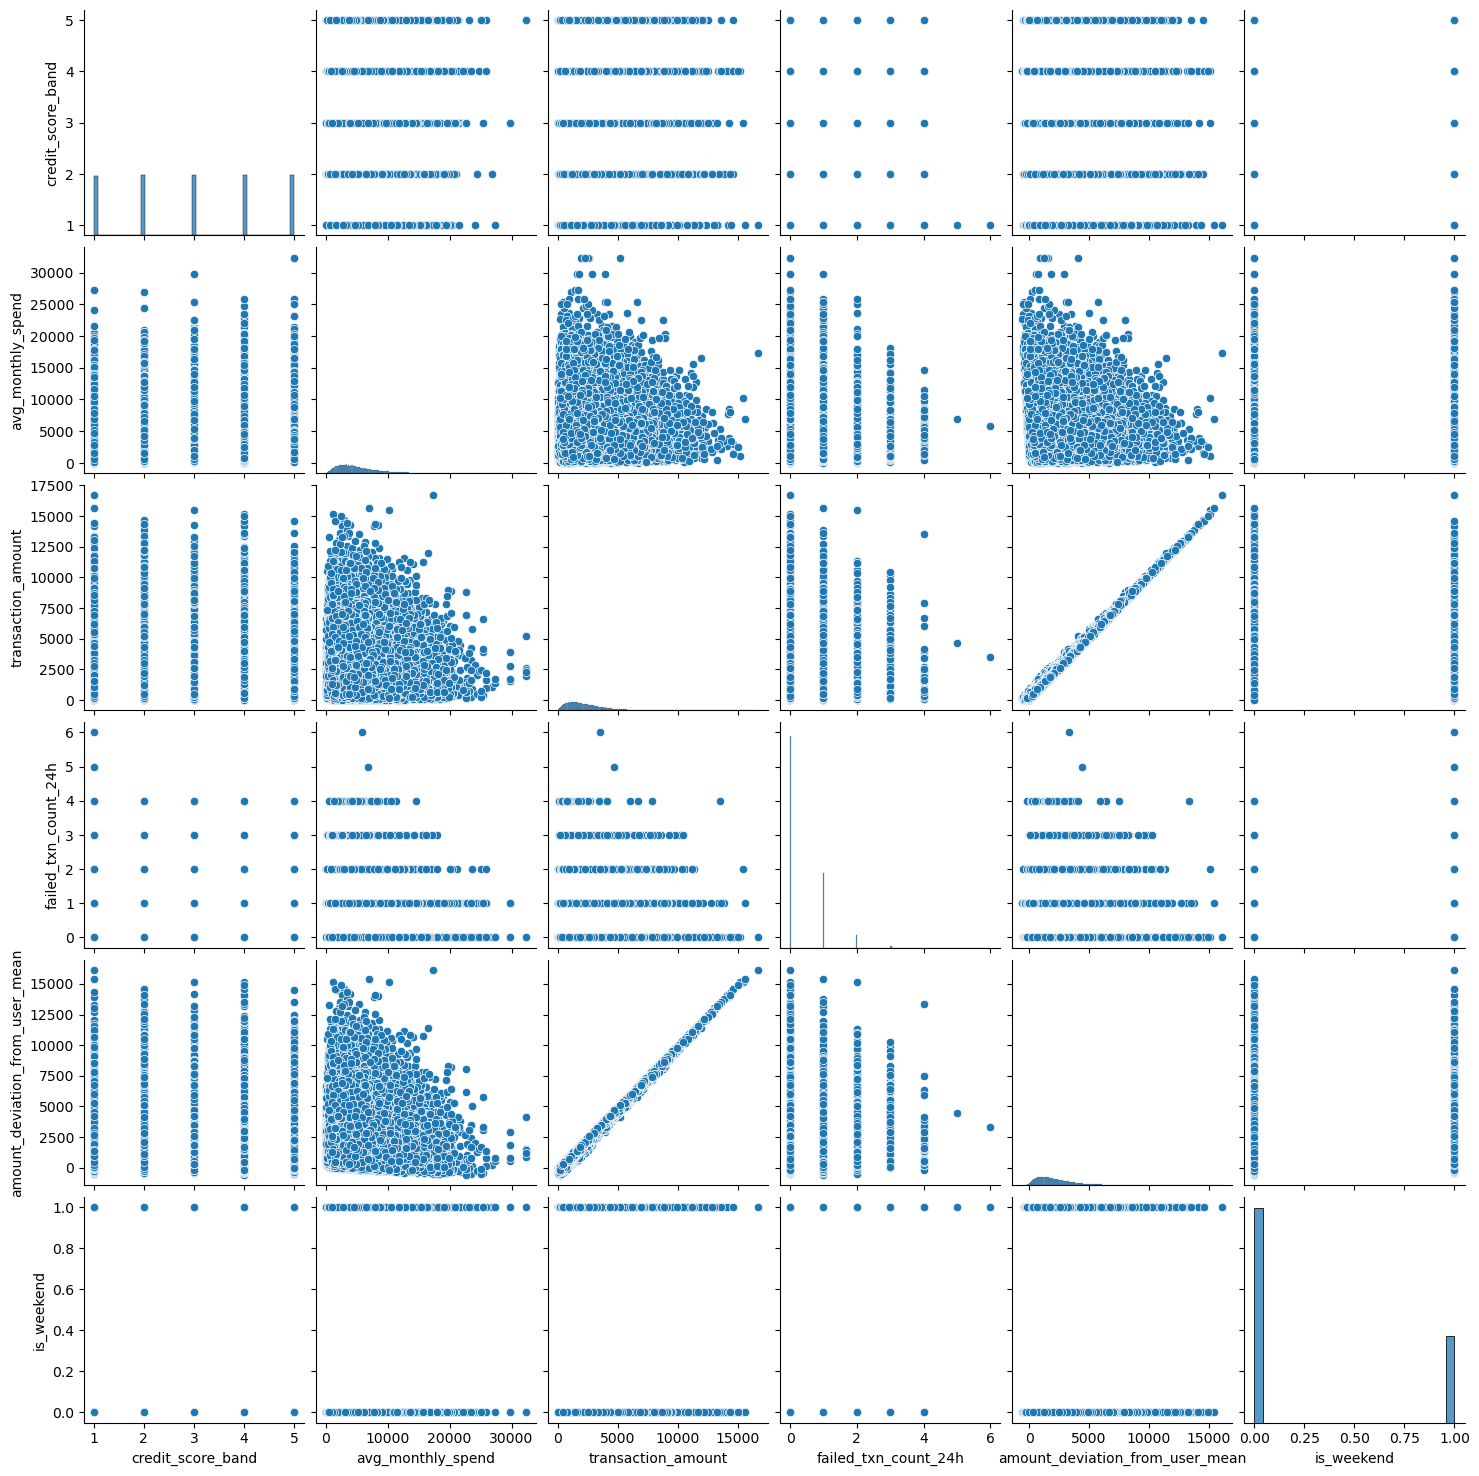

In [10]:
# outliers

cols_outlier_Ayl= ["credit_score_band","avg_monthly_spend","transaction_amount","failed_txn_count_24h","amount_deviation_from_user_mean","is_weekend"]

sns.pairplot(upi[cols_outlier_Ayl])

In [11]:
print("before filtering outliers:", upi.shape)

upi = upi[
    upi["avg_monthly_spend"] < 30000
]

upi = upi[
    upi["failed_txn_count_24h"] < 6
]

print("after filtering outliers:", upi.shape)

before filtering outliers: (99887, 18)
after filtering outliers: (99881, 18)


## Correlation HeatMap

In [12]:
# correlation
num_cols= upi.select_dtypes(include="number")

corr= num_cols.corr()

<Axes: >

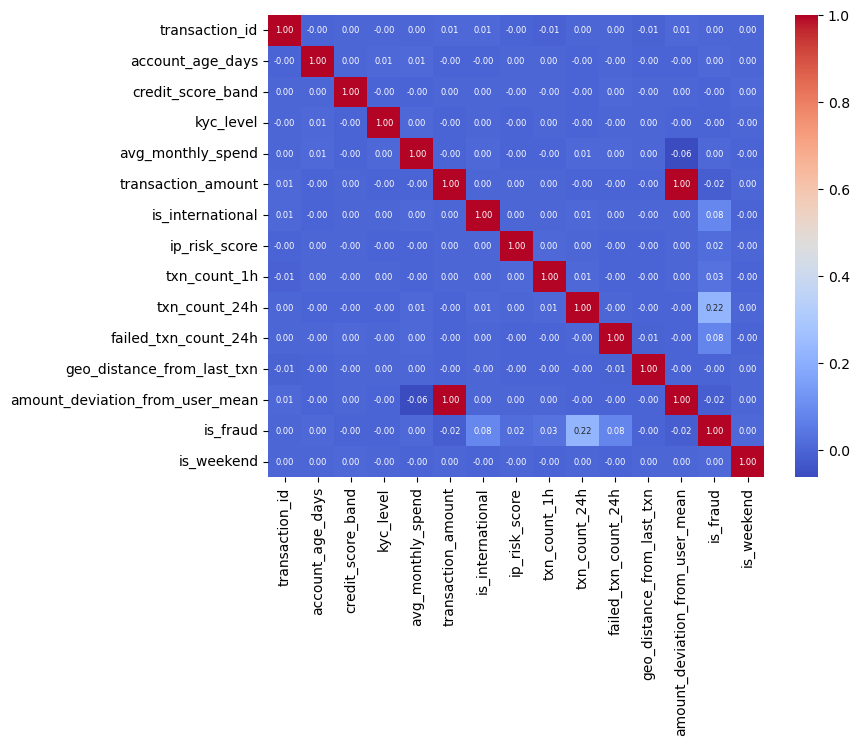

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    fmt=".2f",
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

In [14]:
num_cols.corr()["is_fraud"].sort_values(ascending=False)

is_fraud                           1.000000
txn_count_24h                      0.220187
is_international                   0.082520
failed_txn_count_24h               0.080159
txn_count_1h                       0.030058
ip_risk_score                      0.016754
avg_monthly_spend                  0.004512
is_weekend                         0.003683
account_age_days                   0.003653
transaction_id                     0.002481
kyc_level                         -0.001740
credit_score_band                 -0.002985
geo_distance_from_last_txn        -0.003897
transaction_amount                -0.020787
amount_deviation_from_user_mean   -0.021024
Name: is_fraud, dtype: float64

## Encoding

In [15]:
from sklearn.preprocessing import OneHotEncoder

In [16]:
cat_data=["payment_channel","device_type"]
upi["device_type"].value_counts()
upi["payment_channel"].value_counts()

oh=OneHotEncoder(drop="first")

enc_cols = oh.fit_transform(upi[cat_data])


In [17]:
enc_upi = pd.DataFrame(enc_cols.toarray(), columns=oh.get_feature_names_out(cat_data), index=upi.index)

In [18]:
upi_encoded = pd.concat([upi.drop(columns=cat_data),enc_upi], axis=1)
upi_encoded=upi_encoded.drop("transaction_time",axis=1)

In [19]:
upi_encoded.head()

,transaction_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,transaction_amount,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,is_weekend,payment_channel_card,payment_channel_upi,payment_channel_wallet,device_type_mobile,device_type_tablet
0,305461,1417,4,2,7549.746993,1783.564199,0,0.417366,1,2,0,54.226534,1531.905966,0,1,1.0,0.0,0.0,1.0,0.0
1,341279,830,2,2,2766.322082,7038.755549,0,0.272247,1,3,1,60.728405,6946.544813,0,1,1.0,0.0,0.0,1.0,0.0
2,344364,1651,2,3,3988.151593,663.057016,0,0.446442,3,3,0,102.171038,530.118629,0,1,0.0,1.0,0.0,1.0,0.0
3,84227,1207,1,2,5472.122178,1665.509484,0,0.308703,2,3,0,10.146806,1483.105412,0,1,1.0,0.0,0.0,0.0,0.0
4,187825,1926,5,2,1758.784635,1524.306346,1,0.305401,2,1,1,18.328551,1465.680191,0,1,1.0,0.0,0.0,1.0,0.0


## EDA - exploratory data analysis

In [20]:
is_fraud=upi["is_fraud"].value_counts()
is_fraud

is_fraud
0    97899
1     1982
Name: count, dtype: int64

Text(0.5, 1.0, 'How balanced data is !')

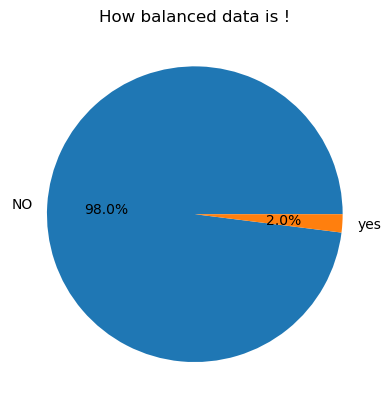

In [21]:
plt.pie(is_fraud, labels=["NO","yes"],autopct="%1.1f%%")
plt.title("How balanced data is !")
# therefore  it's an imbalance data 

## train test split 

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X=upi_encoded.drop("is_fraud",axis=1)
Y=upi_encoded["is_fraud"]

In [24]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [25]:
X_train.shape
X_test.shape
Y_test.shape

(19977,)

## Scaling 

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler= StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Train Models and Evaluation

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score,classification_report

In [29]:
#knn 

step1=([('scaler', StandardScaler()), ('knn',KNeighborsClassifier())])
param_grid={"knn__n_neighbors":[3,5,7,9]}
pipeline=Pipeline(step1)

grid_knn=GridSearchCV(
    pipeline,
    param_grid,
    cv=5
)

grid_knn.fit(X_train,Y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [30]:
# resulting gridserach cross validation 
res= pd.DataFrame(grid_knn.cv_results_)
print(res)

   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.071530      0.006461         3.425361        0.997316   
1       0.068504      0.017645         2.892698        0.188961   
2       0.068222      0.002052         2.995996        0.031057   
3       0.077318      0.004992         3.013856        0.060679   

   param_knn__n_neighbors                   params  split0_test_score  \
0                       3  {'knn__n_neighbors': 3}           0.979225   
1                       5  {'knn__n_neighbors': 5}           0.980227   
2                       7  {'knn__n_neighbors': 7}           0.980414   
3                       9  {'knn__n_neighbors': 9}           0.980289   

   split1_test_score  split2_test_score  split3_test_score  split4_test_score  \
0           0.979788           0.979914           0.980477           0.979599   
1           0.980289           0.980164           0.980289           0.980163   
2           0.980289           0.980227           0.980

In [31]:
print(res[["param_knn__n_neighbors","mean_test_score","rank_test_score"]])

   param_knn__n_neighbors  mean_test_score  rank_test_score
0                       3         0.979801                4
1                       5         0.980226                3
2                       7         0.980314                1
3                       9         0.980239                2


In [32]:
print(grid_knn.best_params_)

{'knn__n_neighbors': 7}


In [33]:
y_pred_knn= grid_knn.predict(X_test)
print("Accurcy score",accuracy_score(Y_test, y_pred_knn))

Accurcy score 0.9802272613505532


In [34]:
print("precision_score",precision_score(Y_test, y_pred_knn))
print("f1_score",f1_score(Y_test, y_pred_knn))
print("recall_score",recall_score(Y_test, y_pred_knn))
print("classification_report",classification_report(Y_test, y_pred_knn))
print("confusion_matrix",confusion_matrix(Y_test, y_pred_knn))

precision_score 0.6
f1_score 0.014962593516209476
recall_score 0.007575757575757576
classification_report               precision    recall  f1-score   support

           0       0.98      1.00      0.99     19581
           1       0.60      0.01      0.01       396

    accuracy                           0.98     19977
   macro avg       0.79      0.50      0.50     19977
weighted avg       0.97      0.98      0.97     19977

confusion_matrix [[19579     2]
 [  393     3]]


In [35]:
from sklearn.svm import SVC

In [36]:
#svc

step2=[('scaler',StandardScaler()),('svc',SVC(C=1.0,kernel='rbf',probability=True))]
pipe= Pipeline(step2)


In [ ]:
pipe.fit(X_train,Y_train)

In [38]:
y_pred_svc=pipe.predict(X_test)

In [39]:
print("Accurcy score",accuracy_score(Y_test, y_pred_svc))
print("precision_score",precision_score(Y_test, y_pred_svc))
print("f1_score",f1_score(Y_test, y_pred_svc))
print("recall_score",recall_score(Y_test, y_pred_svc))
print("classification_report",classification_report(Y_test, y_pred_svc))
print("confusion_matrix",confusion_matrix(Y_test, y_pred_svc))

Accurcy score 0.9804775491815588
precision_score 0.875
f1_score 0.034653465346534656
recall_score 0.017676767676767676
classification_report               precision    recall  f1-score   support

           0       0.98      1.00      0.99     19581
           1       0.88      0.02      0.03       396

    accuracy                           0.98     19977
   macro avg       0.93      0.51      0.51     19977
weighted avg       0.98      0.98      0.97     19977

confusion_matrix [[19580     1]
 [  389     7]]


In [42]:
print("Train Accuracy:", pipe.score(X_train, Y_train))
print("Test Accuracy:", pipe.score(X_test, Y_test))

Train Accuracy: 0.9814402282739287
Test Accuracy: 0.9804775491815588


In [41]:
testypred=pipe.predict(test_sample)

NameError: name 'test_sample' is not defined

In [ ]:
print("classification_report",classification_report(Y_test, testypred))
print("confusion_matrix",confusion_matrix(Y_test, testypred))

In [ ]:
import xgboost as xgb

In [ ]:
model_xgb=xgb.XGBClassifier(
    n_estimators =100,
    max_depth =6,
    learning_rate =0.1,
    eval_metric ="logloss",
    random_state=42
)

In [ ]:
model_xgb.fit(X_train_scaled,Y_train)

In [ ]:
xgb_y_pred=model_xgb.predict(X_test_scaled)

In [ ]:
print("Accurcy score",accuracy_score(Y_test, xgb_y_pred))
print("precision_score",precision_score(Y_test, xgb_y_pred))
print("f1_score",f1_score(Y_test, xgb_y_pred))
print("recall_score",recall_score(Y_test, xgb_y_pred))
print("classification_report",classification_report(Y_test, xgb_y_pred))
print("confusion_matrix",confusion_matrix(Y_test, xgb_y_pred))

## save the model

In [ ]:
import joblib as job

In [ ]:
#job.dump(model_xgb,"C:/Users/vadlu/AIML/projects/fraud_detection/models/fraud_upi_model.pkl")
job.dump(pipe,"C:/Users/vadlu/AIML/projects/FraudShield/models/fraud_upi_model.pkl")


In [ ]:
# test sample

test_sample=X_test.sample(10)
test_sample.to_csv('test_sample.csv',index=False)